In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def self_attention(Q, K, V):
    """Базовый Self-Attention (без визуализации)"""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

def multi_head_attention(Q, K, V, num_heads=2):
    d_model = Q.shape[-1]
    d_k = d_model // num_heads
    
    # Обучаемые проекции (здесь для примера — случайные)
    np.random.seed(42)  # Фиксируем для воспроизводимости
    W_Q = [np.random.randn(d_model, d_k) for _ in range(num_heads)]
    W_K = [np.random.randn(d_model, d_k) for _ in range(num_heads)]
    W_V = [np.random.randn(d_model, d_k) for _ in range(num_heads)]
    W_O = np.random.randn(num_heads * d_k, d_model)
    
    heads = []
    for i in range(num_heads):
        Q_i = Q @ W_Q[i]
        K_i = K @ W_K[i]
        V_i = V @ W_V[i]
        head_out, _ = self_attention(Q_i, K_i, V_i)  # теперь self_attention определена
        heads.append(head_out)
    
    concat = np.hstack(heads)          # (seq_len, num_heads*d_k)
    output = concat @ W_O
    return output

# Пример
seq_len, d_model = 3, 4
Q = np.random.randn(seq_len, d_model)
K = np.random.randn(seq_len, d_model)
V = np.random.randn(seq_len, d_model)

multi_out = multi_head_attention(Q, K, V, num_heads=2)
print("Выход Multi-Head Attention:\n", multi_out)

Выход Multi-Head Attention:
 [[-2.79695819  3.32976806 -1.07204036  0.12017642]
 [-0.39942859  1.27046019 -4.393214   -2.78812499]
 [-2.65955642  2.01038323 -2.26297878 -0.54846047]]


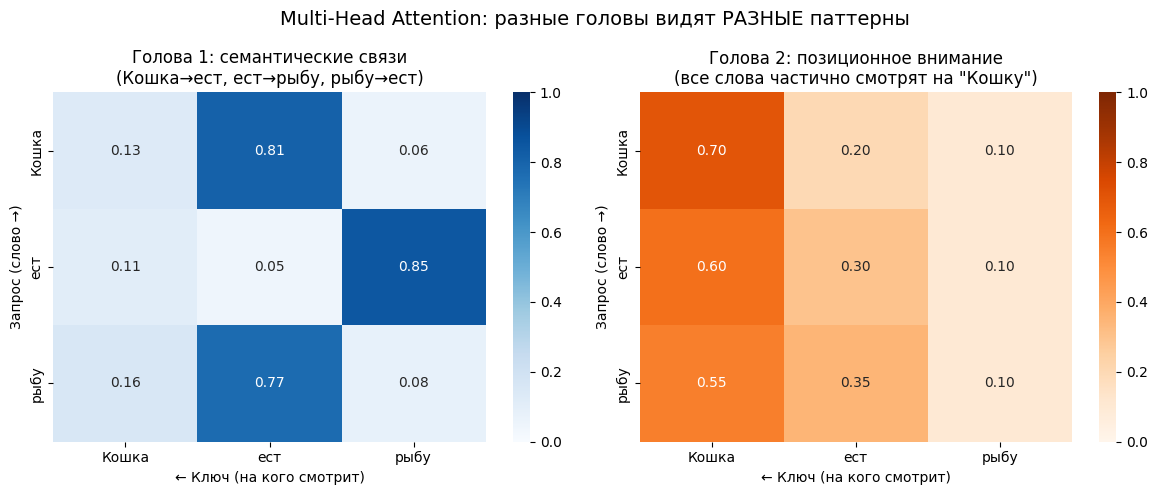


📊 Что демонстрирует этот пример:
- Голова 1 фокусируется на СЕМАНТИКЕ (кто что делает)
- Голова 2 фокусируется на ПОЗИЦИИ (первое слово важно)
- В реальном Transformer'е головы учатся автоматически


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def self_attention_with_weights(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

def multi_head_demo(words):
    """Демонстрация Multi-Head Attention с разными паттернами"""
    
    # Задаём РАЗНЫЕ паттерны для двух голов ВРУЧНУЮ (для наглядности)
    
    # Паттерн Головы 1: классические семантические связи
    head1_weights = np.array([
        [0.13, 0.81, 0.06],  # Кошка → ест
        [0.11, 0.05, 0.85],  # ест → рыбу
        [0.16, 0.77, 0.08]   # рыбу → ест
    ])
    
    # Паттерн Головы 2: акцент на первом слове (позиционное внимание)
    head2_weights = np.array([
        [0.70, 0.20, 0.10],  # Кошка → больше на себя
        [0.60, 0.30, 0.10],  # ест → больше на Кошку
        [0.55, 0.35, 0.10]   # рыбу → больше на Кошку
    ])
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Голова 1
    sns.heatmap(head1_weights, annot=True, fmt='.2f',
                xticklabels=words, yticklabels=words,
                cmap='Blues', ax=axes[0], cbar=True, vmin=0, vmax=1)
    axes[0].set_title('Голова 1: семантические связи\n(Кошка→ест, ест→рыбу, рыбу→ест)')
    axes[0].set_ylabel('Запрос (слово →)')
    axes[0].set_xlabel('← Ключ (на кого смотрит)')
    
    # Голова 2
    sns.heatmap(head2_weights, annot=True, fmt='.2f',
                xticklabels=words, yticklabels=words,
                cmap='Oranges', ax=axes[1], cbar=True, vmin=0, vmax=1)
    axes[1].set_title('Голова 2: позиционное внимание\n(все слова частично смотрят на "Кошку")')
    axes[1].set_ylabel('Запрос (слово →)')
    axes[1].set_xlabel('← Ключ (на кого смотрит)')
    
    plt.suptitle('Multi-Head Attention: разные головы видят РАЗНЫЕ паттерны', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Что демонстрирует этот пример:")
    print("- Голова 1 фокусируется на СЕМАНТИКЕ (кто что делает)")
    print("- Голова 2 фокусируется на ПОЗИЦИИ (первое слово важно)")
    print("- В реальном Transformer'е головы учатся автоматически")

# Запуск
words = ['Кошка', 'ест', 'рыбу']
multi_head_demo(words)